# Context-Aware Kernel Evolution (CAKE)

- Contributors: richardcsuwandi
- Last updated: Aug 17, 2026
- BoTorch version: 0.18.1 (dev)

This notebook is a tutorial for **CAKE** (Context-Aware Kernel Evolution) and **BAKER** (BIC-Acquisition Kernel Ranking), from:

R. C. Suwandi, F. Yin, J. Wang, R. Li, T.-H. Chang, and S. Theodoridis.
[*Adaptive Kernel Design for Bayesian Optimization Is a Piece of CAKE with LLMs*](https://proceedings.neurips.cc/paper_files/paper/2025/file/c03a2610bca2712b984b331fd4f7bb6f-Paper-Conference.pdf).
NeurIPS 2025.

CAKE treats GP kernel design as an evolutionary search. An LLM proposes compositional kernels by crossover and mutation. Each candidate is fit as a BoTorch `SingleTaskGP` and scored with BIC. BAKER then picks the next BO query by jointly ranking model fit and expected improvement, rather than committing to the single best-fitting kernel.

Implementation: `botorch_community/models/cake.py`.


![CAKE overview](cake_overview.png)

*Figure from Suwandi et al., NeurIPS 2025. At each BO iteration, CAKE updates a population of compositional kernels from the current data, then BAKER selects the query.*


## 1. Why kernel evolution?

Bayesian optimization with a GP surrogate is only as good as the kernel. A misspecified kernel (too smooth, missing periodicity, or ignoring linear trends) slows search, especially in the small-data regime. Hand-designing a composition such as $\mathrm{SE} + \mathrm{PER}\times\mathrm{LIN}$ requires expertise, and a kernel chosen *a priori* cannot adapt as more observations arrive.

CAKE automates that search. Base kernels $\{\mathrm{SE}, \mathrm{PER}, \mathrm{LIN}, \mathrm{RQ}, \mathrm{M3}, \mathrm{M5}\}$ are combined with addition and multiplication, following a kernel grammar in the spirit of compositional kernel search. The LLM is used only as the genetic operator: the surrogate remains a GP, so uncertainty-aware BO is preserved.

This notebook is a self-contained tutorial: a synthetic 1D loop on a periodic-plus-trend objective, where a default squared-exponential kernel is misspecified. Smooth 2D benchmarks such as Branin are already well fit by Matérn-5/2, so they are a poor place to see kernel evolution help. For HPOBench, controller tuning, and photonic chip results, see [the paper](https://proceedings.neurips.cc/paper_files/paper/2025/file/c03a2610bca2712b984b331fd4f7bb6f-Paper-Conference.pdf).


## 2. Method

### Kernel grammar

Let $\mathbb{K}_0$ be the set of base kernels and $\{+, \times\}$ the operators. The grammar is defined recursively by

$$
\mathbb{K}_0 = \{k_1,\ldots,k_r\}, \qquad
\mathbb{K}_i = \{\mathcal{T}(k,k') : k,k'\in\mathbb{K}_{i-1},\; \mathcal{T}\in\{+,\times\}\} \cup \mathbb{K}_{i-1}.
$$

Each occurrence of a base kernel is a fresh GPyTorch module, so `SE + SE` does not share lengthscales. The parser wraps the composition in an outer `ScaleKernel`.


![Kernel grammar](cake_kernel_grammar.png)

*Base kernels and operators used by CAKE (Suwandi et al., NeurIPS 2025).*


### Fitness: BIC

Each kernel $k$ is fit by maximizing the exact GP marginal likelihood. Fitness is the Bayesian information criterion (lower is better):

$$
\mathrm{BIC}(k) = -2\log p(\mathbf{y} \mid \mathbf{X}, \hat{\boldsymbol{\theta}}_k) + p_k \log n,
$$

where $\hat{\boldsymbol{\theta}}_k$ are the fitted hyperparameters and $p_k$ is the number of free parameters. After scoring, CAKE keeps the top $n_p$ kernels.

### Evolution

At BO iteration $t$, with observations $\mathcal{D}_t$:

1. **Crossover** ($n_c$ times): sample two parents with probability proportional to $\exp(-\mathrm{BIC})$, and ask the LLM to combine them with $+$ or $\times$.
2. **Mutation** (with probability $p_m$): replace one base kernel in the current fittest expression.
3. Refit, score, and retain the top $n_p$ kernels.

The paper used $n_c=5$, $p_m=0.7$, $n_p=10$, and `gpt-4o-mini`. This notebook uses lighter defaults and an algebraic stand-in for the LLM so it runs offline.

### BAKER

A kernel can fit the data well and still propose a weak query. BAKER ranks each surviving kernel by a fitness weight times acquisition value:

$$
w_k = \frac{\exp(-\mathrm{BIC}_k)}{\sum_{k'} \exp(-\mathrm{BIC}_{k'})}, \qquad
k^\star = \arg\max_{k\in\mathbb{K}} \; w_k \, \alpha(\mathbf{x}_{t,k}; \mathcal{D}_t, k),
$$

where $\mathbf{x}_{t,k}$ is the candidate obtained by maximizing $\alpha(\cdot)$ under kernel $k$. The paper used expected improvement. This implementation uses `LogExpectedImprovement` and ranks by $\log w_k + \mathrm{LogEI}$, which is equivalent for $\arg\max$.


## 3. Setup

The cells below honor `SMOKE_TEST` for a short CI-style run. Leave it unset for the tutorial budget used to produce the saved figures.


In [1]:
%matplotlib inline

import os
import warnings

import matplotlib.pyplot as plt
import torch
from botorch.acquisition.analytic import LogExpectedImprovement
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.optim import optimize_acqf
from botorch_community.models.cake import (
    AlgebraicLLMClient,
    CAKE,
    fit_kernel_gp,
    parse_kernel_expression,
)
from gpytorch.mlls import ExactMarginalLogLikelihood
from IPython.display import display

warnings.filterwarnings("ignore")
SMOKE_TEST = bool(os.environ.get("SMOKE_TEST"))
torch.set_default_dtype(torch.double)
torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})

print("SMOKE_TEST:", SMOKE_TEST)


/Users/richardsuwandi/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SMOKE_TEST: False


## 4. Parsing a compositional kernel

`parse_kernel_expression` turns a string into a GPyTorch module. Addition and multiplication are left-associative with equal precedence, matching the original CAKE parser.


In [2]:
kernel = parse_kernel_expression("(SE + PER) * LIN", ard_num_dims=2)
print(kernel)

se_plus_se = parse_kernel_expression("SE + SE", ard_num_dims=1)
left, right = se_plus_se.base_kernel.kernels
print("repeated SE terms share a module:", left is right)


ScaleKernel(
  (base_kernel): ProductKernel(
    (kernels): ModuleList(
      (0): AdditiveKernel(
        (kernels): ModuleList(
          (0): RBFKernel(
            (raw_lengthscale_constraint): Positive()
          )
          (1): PeriodicKernel(
            (raw_lengthscale_constraint): Positive()
            (raw_period_length_constraint): Positive()
          )
        )
      )
      (1): LinearKernel(
        (raw_variance_constraint): Positive()
      )
    )
  )
  (raw_outputscale_constraint): Positive()
)
repeated SE terms share a module: False


### A 1D illustration

On data with a periodic trend plus a linear drift, a stationary `SE` kernel underfits the structure, while `SE + PER` (a typical CAKE proposal) captures both components. This is the kind of pattern the evolutionary search is meant to discover.


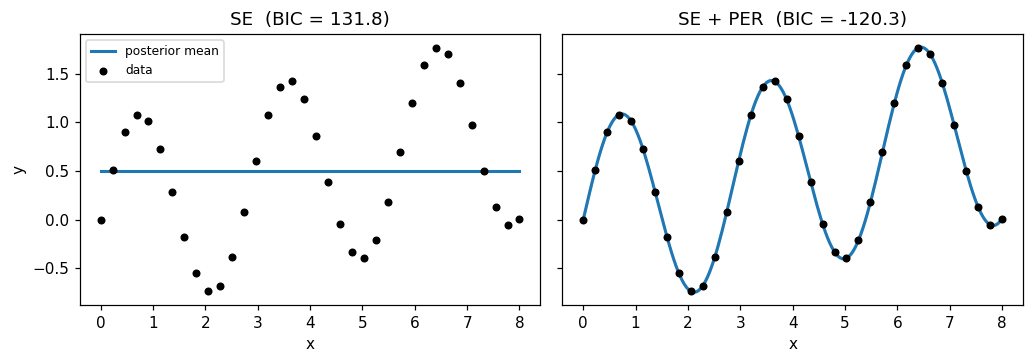

In [3]:
x = torch.linspace(0.0, 8.0, 36).unsqueeze(-1)
y = torch.sin(2.2 * x) + 0.12 * x
xx = torch.linspace(0.0, 8.0, 200).unsqueeze(-1)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=True)
for ax, expr in zip(axes, ("SE", "SE + PER")):
    model, bic = fit_kernel_gp(x, y, kernel_expression=expr)
    post = model.posterior(xx)
    mean = post.mean.squeeze(-1).detach()
    std = post.variance.sqrt().squeeze(-1).detach()
    ax.fill_between(
        xx.squeeze().numpy(),
        (mean - 2 * std).numpy(),
        (mean + 2 * std).numpy(),
        alpha=0.25,
        color="C0",
    )
    ax.plot(xx.numpy(), mean.numpy(), color="C0", lw=2, label="posterior mean")
    ax.scatter(x.numpy(), y.numpy(), c="k", s=18, zorder=3, label="data")
    ax.set_title(f"{expr}  (BIC = {bic:.1f})")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig("cake_fit_1d.png", bbox_inches="tight")
display(fig)
plt.close(fig)


## 5. LLM backends

CAKE talks to a chat client through a minimal `complete(system_prompt, user_message)` interface.

- `OpenAILLMClient()`: OpenAI API, default `gpt-5-mini`. Pass `model="gpt-4o-mini"` to match the paper. Requires `pip install openai` and `OPENAI_API_KEY`.
- `OllamaLLMClient()`: local Ollama via the OpenAI-compatible `/v1` endpoint (`ollama serve` and a pulled model).
- `AlgebraicLLMClient`: no network. Applies $+$ / $\times$ crossover and base-kernel mutation. Used below so the notebook is deterministic and CI-safe.
- `ScriptedLLMClient`: canned `Kernel:` responses for unit tests.

```python
from botorch_community.models.cake import OllamaLLMClient, OpenAILLMClient

# llm_client = OpenAILLMClient()                       # gpt-5-mini
# llm_client = OpenAILLMClient(model="gpt-4o-mini")    # paper
# llm_client = OllamaLLMClient(model="llama3.2")
```


## 6. Synthetic BO demo

We maximize the same 1D family as in Section 4,

$$
f(x) = \sin(2.2 x) + 0.12 x, \qquad x \in [0, 8].
$$

A stationary `SE` kernel cannot represent the oscillation (see the BIC plot above), so LogEI with a fixed `SE` GP often wastes evaluations on the domain boundary. CAKE's population includes `PER`, so BAKER can switch to a periodic or `PER + M3` kernel and lock onto the global peak sooner.

This is a tutorial run (one seed, algebraic operators, light population), not a reproduction of the paper tables. Swap in `OpenAILLMClient(model="gpt-4o-mini")` for the paper setting.


In [4]:
def objective(X: torch.Tensor) -> torch.Tensor:
    x = X[..., 0]
    return torch.sin(2.2 * x) + 0.12 * x


bounds = torch.tensor([[0.0], [8.0]])
n_init = 4 if SMOKE_TEST else 6
n_iter = 2 if SMOKE_TEST else 8
num_restarts = 2 if SMOKE_TEST else 8
raw_samples = 8 if SMOKE_TEST else 32
population_size = 3 if SMOKE_TEST else 6

xx = torch.linspace(bounds[0, 0].item(), bounds[1, 0].item(), 500).unsqueeze(-1)
true_max = float(objective(xx).max())

train_X = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(n_init, 1)
train_Y = objective(train_X).unsqueeze(-1)
print(f"init: n={n_init}, best={float(train_Y.max()):.3f}, true max={true_max:.3f}")


init: n=6, best=1.737, true max=1.773


### CAKE + BAKER


In [5]:
llm_client = AlgebraicLLMClient(seed=0)
cake = CAKE(
    llm_client=llm_client,
    num_crossover=1,
    mutation_prob=0.7,
    population_size=population_size,
    num_restarts=num_restarts,
    raw_samples=raw_samples,
    maximize=True,
    seed=0,
)

cake_X, cake_Y = train_X.clone(), train_Y.clone()
cake_best = [float(cake_Y.max())]
cake_kernels = []

for i in range(n_iter):
    cake.fit(cake_X, cake_Y)
    query = cake.get_next_query(bounds)
    new_Y = objective(query.X).unsqueeze(-1)
    cake_X = torch.cat([cake_X, query.X], dim=0)
    cake_Y = torch.cat([cake_Y, new_Y], dim=0)
    cake_best.append(float(cake_Y.max()))
    cake_kernels.append(query.kernel_expression)
    print(
        f"iter {i + 1:02d} | {query.kernel_expression:<22} | "
        f"best={cake_best[-1]:.3f}"
    )

print("final best kernel:", cake.best_kernel)
print("final BIC:", f"{cake.best_bic:.2f}")


iter 01 | (PER) + (M3)           | best=1.737


iter 02 | PER                    | best=1.737


iter 03 | PER                    | best=1.773


iter 04 | PER                    | best=1.773


iter 05 | PER                    | best=1.773


iter 06 | M3                     | best=1.773


iter 07 | (PER) + (M3)           | best=1.773


iter 08 | (PER) + (M3)           | best=1.773
final best kernel: (PER) + (M3)
final BIC: 19.21


### Fixed `SE` baseline

The comparison is a `SingleTaskGP` with a **fixed squared-exponential kernel**, the misspecified model from Section 4, plus LogEI. A default Matérn-5/2 GP is already a strong generic smoother and would hide the point of kernel search. After `fit`, `cake.best_model` can still be used with any BoTorch acquisition function.


In [6]:
base_X, base_Y = train_X.clone(), train_Y.clone()
base_best = [float(base_Y.max())]

for i in range(n_iter):
    model = SingleTaskGP(
        base_X,
        base_Y,
        covar_module=parse_kernel_expression("SE", ard_num_dims=1),
        input_transform=Normalize(d=1),
        outcome_transform=Standardize(m=1),
    )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    acqf = LogExpectedImprovement(model=model, best_f=base_Y.max())
    candidate, _ = optimize_acqf(
        acq_function=acqf,
        bounds=bounds,
        q=1,
        num_restarts=num_restarts,
        raw_samples=raw_samples,
    )
    new_Y = objective(candidate).unsqueeze(-1)
    base_X = torch.cat([base_X, candidate], dim=0)
    base_Y = torch.cat([base_Y, new_Y], dim=0)
    base_best.append(float(base_Y.max()))


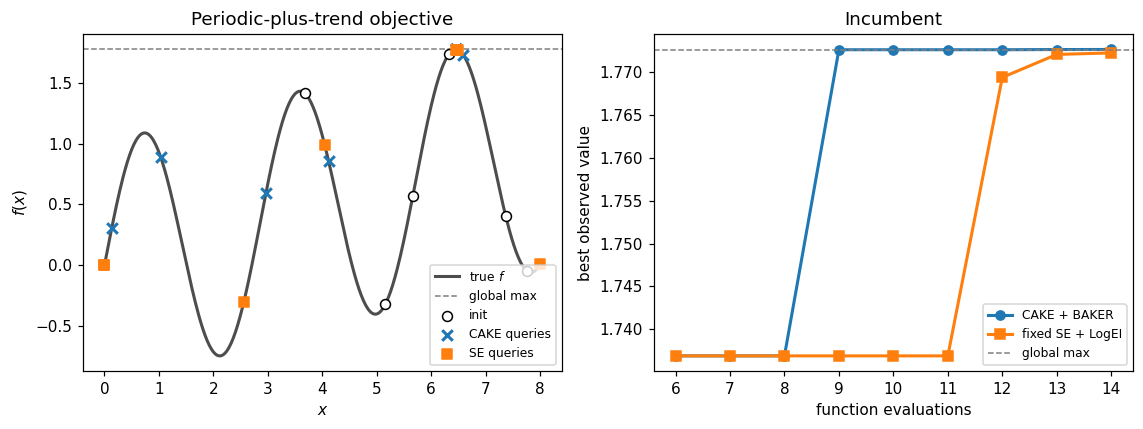

In [7]:
xx_plot = torch.linspace(bounds[0, 0].item(), bounds[1, 0].item(), 400).unsqueeze(-1)
f_plot = objective(xx_plot)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))

ax = axes[0]
ax.plot(xx_plot.numpy(), f_plot.numpy(), color="0.3", lw=2, label=r"true $f$")
ax.axhline(true_max, color="0.5", ls="--", lw=1, label="global max")
ax.scatter(
    train_X.numpy(),
    train_Y.numpy(),
    c="white",
    edgecolors="k",
    s=42,
    zorder=3,
    label="init",
)
ax.scatter(
    cake_X[n_init:].numpy(),
    cake_Y[n_init:].numpy(),
    c="C0",
    s=48,
    marker="x",
    linewidths=2,
    zorder=4,
    label="CAKE queries",
)
ax.scatter(
    base_X[n_init:].numpy(),
    base_Y[n_init:].numpy(),
    c="C1",
    s=36,
    marker="s",
    zorder=4,
    label="SE queries",
)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.set_title("Periodic-plus-trend objective")
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
evals = list(range(n_init, n_init + n_iter + 1))
ax.plot(evals, cake_best, marker="o", lw=2, label="CAKE + BAKER")
ax.plot(evals, base_best, marker="s", lw=2, label="fixed SE + LogEI")
ax.axhline(true_max, color="0.5", ls="--", lw=1, label="global max")
ax.set_xlabel("function evaluations")
ax.set_ylabel("best observed value")
ax.set_title("Incumbent")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("cake_bo_run.png", bbox_inches="tight")
display(fig)
plt.close(fig)


On this seed, CAKE switches to a periodic kernel (`PER` / `PER + M3`) and reaches the global peak while the fixed `SE` model still spends queries on the boundary. That is the misspecification story from Section 4 of the paper, now inside a BO loop.

The run uses `AlgebraicLLMClient` (no API call). It is an API demonstration, not a reproduction of the paper tables. Those use `gpt-4o-mini` with $n_c=5$ and $n_p=10$. See [the paper](https://proceedings.neurips.cc/paper_files/paper/2025/file/c03a2610bca2712b984b331fd4f7bb6f-Paper-Conference.pdf) for HPOBench, controller, and photonic chip results.


## 7. Using the evolved model

After `fit`, `cake.best_model` is a fitted `SingleTaskGP`. You can plug it into any BoTorch acquisition function, not only BAKER.


In [8]:
model = cake.best_model
acqf = LogExpectedImprovement(model=model, best_f=cake_Y.max())
x_star, log_ei = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=1,
    num_restarts=num_restarts,
    raw_samples=raw_samples,
)
print("best kernel:", cake.best_kernel)
print("candidate:", x_star.detach().squeeze().tolist())
print("LogEI:", float(log_ei))


best kernel: (PER) + (M3)
candidate: 6.449363618340493
LogEI: -5.41259336731247
